In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns



Total de jogos: 488
Vitórias do time 1 (team_1): 250
Vitórias do time 2 (team_2): 238
Percentual de vitórias do lado azul: 51.23%


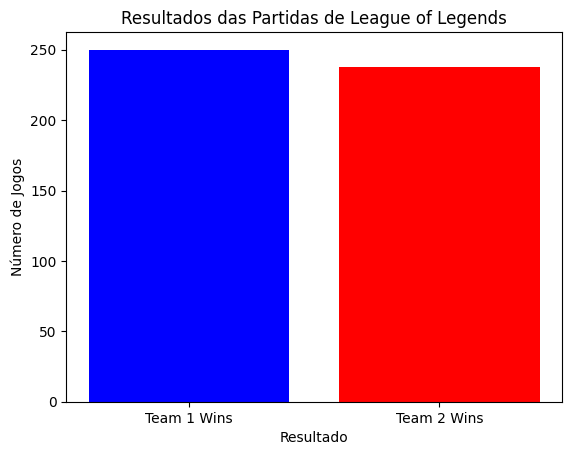

In [2]:
file_path = '../../repository/lck/LCK_matches_2.csv'

# Carregar os dados organizados
df = pd.read_csv(file_path)

# Total de jogos
total_matches = df.shape[0]

# Contagem de vitórias
team_1_wins = (df['winner'] == df['team_1']).sum()
team_2_wins = (df['winner'] == df['team_2']).sum()


# Lista de valores para os times e seus resultados
win_counts = [team_1_wins, team_2_wins]

# Cálculo da porcentagem de vitórias do time 1
team_1_win_rate = (team_1_wins / total_matches) * 100

# Exibir estatísticas
print("Total de jogos:", total_matches)
print("Vitórias do time 1 (team_1):", team_1_wins)
print("Vitórias do time 2 (team_2):", team_2_wins)
print(f"Percentual de vitórias do lado azul: {team_1_win_rate:.2f}%")

# Criar gráfico de barras
x = ['Team 1 Wins', 'Team 2 Wins']
y = win_counts

plt.bar(x, y, color=['blue', 'red'])
plt.xlabel('Resultado')
plt.ylabel('Número de Jogos')
plt.title('Resultados das Partidas de League of Legends')
plt.show()


In [3]:
matches_df = pd.read_csv(file_path)
# Ordenar os dados pelas datas dos jogos para manter a ordem cronológica
# Pois temos informação temporal.
matches_df = matches_df.sort_values(by='date')
print(matches_df.head())

                  match_id            team_1               team_2 league  \
460  ESPORTSTMNT04_2659018         Dplus KIA                  DRX    LCK   
462  ESPORTSTMNT04_2661035         Dplus KIA                  DRX    LCK   
461  ESPORTSTMNT04_2660040                T1                Gen.G    LCK   
463  ESPORTSTMNT04_2661049                T1                Gen.G    LCK   
477  ESPORTSTMNT04_2665017  Kwangdong Freecs  Hanwha Life Esports    LCK   

                    date               winner  
460  2023-01-18 08:17:31            Dplus KIA  
462  2023-01-18 09:13:04            Dplus KIA  
461  2023-01-18 11:00:07                   T1  
463  2023-01-18 11:59:24                   T1  
477  2023-01-19 08:20:39  Hanwha Life Esports  


In [4]:
# Encode team names and league
le_team = LabelEncoder()
le_league = LabelEncoder()

matches_df['game_id'] = matches_df.index
matches_df['team_1_encoded'] = le_team.fit_transform(matches_df['team_1'])
matches_df['team_2_encoded'] = le_team.fit_transform(matches_df['team_2'])
matches_df['league_encoded'] = le_league.fit_transform(matches_df['league'])
matches_df['result_encoded'] = (matches_df['winner'] == matches_df['team_1']).astype(int)

# Variáveis que serão usadas para treinar o modelo
# Features: (team names 1: team names 2 : league)
X = matches_df[['team_1_encoded', 'team_2_encoded', 'league_encoded']]

# Target: vencedor (codificado como 0 ou 1 com base em se o time_1 é o vencedor)
y = matches_df['result_encoded']

display(matches_df.head())

,match_id,team_1,team_2,league,date,winner,game_id,team_1_encoded,team_2_encoded,league_encoded,result_encoded
460,ESPORTSTMNT04_2659018,Dplus KIA,DRX,LCK,2023-01-18 08:17:31,Dplus KIA,460,2,1,0,1
462,ESPORTSTMNT04_2661035,Dplus KIA,DRX,LCK,2023-01-18 09:13:04,Dplus KIA,462,2,1,0,1
461,ESPORTSTMNT04_2660040,T1,Gen.G,LCK,2023-01-18 11:00:07,T1,461,10,3,0,1
463,ESPORTSTMNT04_2661049,T1,Gen.G,LCK,2023-01-18 11:59:24,T1,463,10,3,0,1
477,ESPORTSTMNT04_2665017,Kwangdong Freecs,Hanwha Life Esports,LCK,2023-01-19 08:20:39,Hanwha Life Esports,477,6,4,0,0


In [5]:
# Normalização dos dados de entrada (features)
scaler = MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)
print('Features: ', X_scaled.shape)
print(X_scaled)

Features:  (488, 3)
[[0.2 0.1 0. ]
 [0.2 0.1 0. ]
 [1.  0.3 0. ]
 ...
 [0.3 1.  0. ]
 [1.  0.3 0. ]
 [0.3 1.  0. ]]


In [6]:
# Definir percentuais de treino, teste e previsão
# Treino      representa 80% dos dados
# Teste       representa 10% dos dados
# Previsão    representa 10% dos dados
train_ratio = 0.8
test_ratio = 0.1

# Calcular os índices para separação
total_matches = matches_df.shape[0]

train_size = int(train_ratio * total_matches)
test_size = int(test_ratio * total_matches)

# Separação manual dos dados
X_train = X_scaled[:train_size]
y_train = y[:train_size]

X_test = X_scaled[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

X_prediction = X_scaled[train_size + test_size:]

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))


390 390
48 48


In [7]:
# Criar o modelo Naive Bayes
model = GaussianNB()

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average = 'micro')

print(f'Acurácia do modelo de Naive Bayes: {accuracy * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')

Acurácia do modelo de Naive Bayes: 54.17%
F1 Score: 54.17%%


In [8]:
# Criar o modelo de Regressão Logística
logistic_model = LogisticRegression()

# Treinar o modelo
logistic_model.fit(X_train, y_train)

# Fazer previsões
y_pred_logistic = logistic_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic, average = 'micro')

print(f'Acurácia do modelo de Regressão Logística: {accuracy_logistic * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


Acurácia do modelo de Regressão Logística: 54.17%
F1 Score: 54.17%%


In [9]:
# Criar o modelo SVM
svm_model = SVC()

# Treinar o modelo SVM
svm_model.fit(X_train, y_train)

# Fazer previsões com o modelo SVM
y_pred_svm = svm_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm, average = 'micro')


print(f'Acurácia do modelo SVM: {accuracy_svm * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


Acurácia do modelo SVM: 58.33%
F1 Score: 58.33%%


In [10]:
# Criar o modelo de Árvore de Decisão
tree_model = DecisionTreeClassifier()

# Treinar o modelo de Árvore de Decisão
tree_model.fit(X_train, y_train)

# Fazer previsões com o modelo de Árvore de Decisão
y_pred_tree = tree_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1 = f1_score(y_test, y_pred_tree, average = 'micro')


print(f'Acurácia do modelo de Árvore de Decisão: {accuracy_tree * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')

Acurácia do modelo de Árvore de Decisão: 64.58%
F1 Score: 64.58%%


In [11]:
# Executando a previsão pelo método de maior acurácia (Árvore de Decisão)
prevision = X_prediction
game_id = matches_df['game_id']
game_id_prev = game_id[train_size + test_size:]

result = matches_df['result_encoded']
result_prev = result[train_size + test_size:]

pred = tree_model.predict(prevision)



df = pd.DataFrame({'Resultado': result_prev, 'Previsão': pred, 'Game_id': game_id_prev})
print(df[:10])


     Resultado  Previsão  Game_id
128          1         1      128
133          1         1      133
134          0         1      134
129          0         0      129
135          0         0      135
130          1         1      130
136          1         0      136
131          1         1      131
140          1         0      140
137          1         1      137


<Axes: xlabel='Previsão', ylabel='Resultado'>

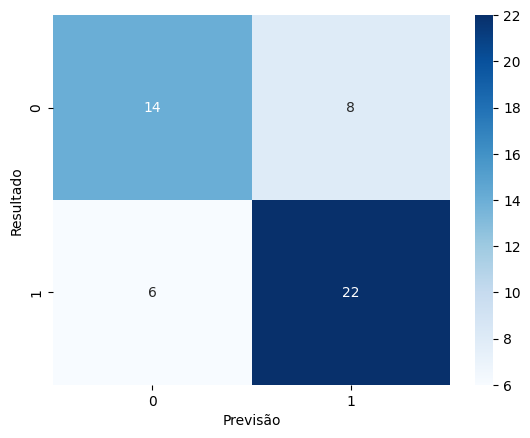

In [12]:
#Matrix de confusão
df = pd.DataFrame(df,columns = ['Resultado','Previsão'])

cf_matrix = pd.crosstab(df['Resultado'], df['Previsão'], rownames = ['Resultado'] , colnames = ['Previsão'])

sns.heatmap(cf_matrix, annot = True, cmap = 'Blues', fmt = 'g')